# Backdoor Attack, Activation Clustering, and Repair on CIFAR-10 with ResNet-18

In [1]:
import os
import json
import math
import copy
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA, PCA
from sklearn.cluster import KMeans
from sklearn.metrics import precision_score, recall_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
import torchvision.transforms as T
import torchvision.models as models

# -----------------------------
# Config
# -----------------------------
CONFIG = {
    "seed": 42,
    "data_dir": "./data",
    "out_dir": "./outputs",
    "num_classes": 10,
    "target_class": 0,              # recommended by assignment
    "val_per_class": 500,           # balanced clean validation split
    "poison_rate": 0.05,            # 5% of non-target training samples
    "trigger_size": 3,              # 3x3 white square
    "trigger_value": 1.0,           # pixel value in [0,1]
    "trigger_offset": 1,            # 1 pixel away from bottom-right border
    "batch_size": 128,
    "num_workers": 2,
    "epochs": 30,
    "lr": 0.1,
    "momentum": 0.9,
    "weight_decay": 5e-4,
    "ica_components": 10,
    "kmeans_n_init": 20,
    "feature_batch_size": 256,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

OUT_DIR = Path(CONFIG["out_dir"])
FIG_DIR = OUT_DIR / "figures"
CKPT_DIR = OUT_DIR / "checkpoints"
META_DIR = OUT_DIR / "metadata"

for d in [OUT_DIR, FIG_DIR, CKPT_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

with open(OUT_DIR / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

print("Device:", CONFIG["device"])
print("Outputs will be saved to:", OUT_DIR.resolve())

Device: cuda
Outputs will be saved to: /content/outputs


In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Determinism settings
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])

### Dataset split and poisoning design
We create:
- a balanced clean validation split of 500 samples per class,
- a clean training split from the remaining CIFAR-10 training samples,
- a poisoned training split by poisoning 5% of non-target training examples.

Poisoned samples:
- receive a fixed 3x3 white square trigger in the bottom-right corner,
- are relabeled to the target class.

In [3]:
train_transform = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
])

eval_transform = T.Compose([
    T.ToTensor(),
])

In [4]:
base_train_raw = torchvision.datasets.CIFAR10(
    root=CONFIG["data_dir"], train=True, download=True
)
base_test_raw = torchvision.datasets.CIFAR10(
    root=CONFIG["data_dir"], train=False, download=True
)

train_targets = np.array(base_train_raw.targets)

def make_balanced_val_split(targets, val_per_class=500, seed=42, num_classes=10):
    rng = np.random.default_rng(seed)
    val_indices = []
    train_indices = []

    for cls in range(num_classes):
        cls_indices = np.where(targets == cls)[0]
        rng.shuffle(cls_indices)
        val_cls = cls_indices[:val_per_class]
        train_cls = cls_indices[val_per_class:]
        val_indices.extend(val_cls.tolist())
        train_indices.extend(train_cls.tolist())

    return np.array(train_indices), np.array(val_indices)

train_indices, val_indices = make_balanced_val_split(
    train_targets,
    val_per_class=CONFIG["val_per_class"],
    seed=CONFIG["seed"],
    num_classes=CONFIG["num_classes"],
)

print("Train split:", len(train_indices))
print("Val split:", len(val_indices))

pd.DataFrame({"train_indices": train_indices}).to_csv(META_DIR / "train_indices.csv", index=False)
pd.DataFrame({"val_indices": val_indices}).to_csv(META_DIR / "val_indices.csv", index=False)

100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


Train split: 45000
Val split: 5000


#### Trigger and poisoning utilities

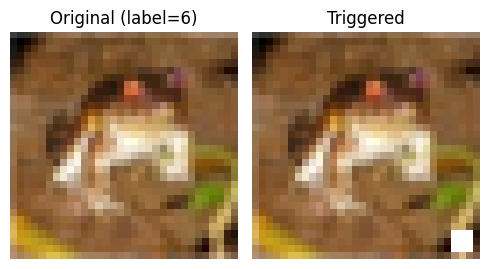

In [5]:
def add_trigger_to_tensor(img_tensor, trigger_size=3, value=1.0, offset=1):
    """
    img_tensor: torch.Tensor of shape [C, H, W] with values in [0,1]
    Places a square trigger in the bottom-right corner.
    """
    x = img_tensor.clone()
    _, h, w = x.shape

    r_end = h - offset
    c_end = w - offset
    r_start = r_end - trigger_size
    c_start = c_end - trigger_size

    x[:, r_start:r_end, c_start:c_end] = value
    return x

def visualize_trigger_example(dataset, idx=0):
    img, label = dataset[idx]
    triggered = add_trigger_to_tensor(
        img,
        trigger_size=CONFIG["trigger_size"],
        value=CONFIG["trigger_value"],
        offset=CONFIG["trigger_offset"]
    )

    fig, axes = plt.subplots(1, 2, figsize=(5, 3))
    axes[0].imshow(np.transpose(img.numpy(), (1, 2, 0)))
    axes[0].set_title(f"Original (label={label})")
    axes[0].axis("off")

    axes[1].imshow(np.transpose(triggered.numpy(), (1, 2, 0)))
    axes[1].set_title("Triggered")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

temp_eval_train = torchvision.datasets.CIFAR10(
    root=CONFIG["data_dir"], train=True, download=False, transform=eval_transform
)
visualize_trigger_example(temp_eval_train, idx=0)

#### Decide which train samples to poison

In [6]:
train_targets_subset = train_targets[train_indices]
non_target_mask = train_targets_subset != CONFIG["target_class"]
non_target_positions = np.where(non_target_mask)[0]

num_poison = int(round(CONFIG["poison_rate"] * len(non_target_positions)))
rng = np.random.default_rng(CONFIG["seed"])
poison_positions_in_train_subset = rng.choice(
    non_target_positions, size=num_poison, replace=False
)

poison_mask_train_subset = np.zeros(len(train_indices), dtype=bool)
poison_mask_train_subset[poison_positions_in_train_subset] = True

poisoned_original_indices = train_indices[poison_mask_train_subset]

poison_meta = pd.DataFrame({
    "subset_pos": np.arange(len(train_indices)),
    "original_index": train_indices,
    "original_label": train_targets_subset,
    "is_poisoned": poison_mask_train_subset.astype(int)
})
poison_meta["observed_label"] = poison_meta["original_label"]
poison_meta.loc[poison_meta["is_poisoned"] == 1, "observed_label"] = CONFIG["target_class"]
poison_meta.to_csv(META_DIR / "poison_metadata.csv", index=False)

print("Total clean-train examples:", len(train_indices))
print("Non-target train examples:", len(non_target_positions))
print("Num poisoned:", num_poison)

Total clean-train examples: 45000
Non-target train examples: 40500
Num poisoned: 2025


#### Dataset wrappers

In [7]:
class IndexedCIFAR10(Dataset):
    """
    Returns:
      image, label, original_index
    """
    def __init__(self, root, train, indices, transform):
        self.dataset = torchvision.datasets.CIFAR10(
            root=root, train=train, download=False, transform=transform
        )
        self.indices = np.array(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        original_index = int(self.indices[i])
        img, label = self.dataset[original_index]
        return img, label, original_index


class PoisonedCIFAR10Train(Dataset):
    """
    Returns:
      image, observed_label, original_label, is_poisoned, original_index, subset_pos
    """
    def __init__(self, root, indices, poison_mask_subset, target_class, transform,
                 trigger_size=3, trigger_value=1.0, trigger_offset=1):
        self.dataset = torchvision.datasets.CIFAR10(
            root=root, train=True, download=False, transform=transform
        )
        self.indices = np.array(indices)
        self.poison_mask_subset = np.array(poison_mask_subset).astype(bool)
        self.target_class = target_class
        self.trigger_size = trigger_size
        self.trigger_value = trigger_value
        self.trigger_offset = trigger_offset

        targets = np.array(self.dataset.targets)
        self.original_labels = targets[self.indices]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        original_index = int(self.indices[i])
        img, original_label = self.dataset[original_index]
        is_poisoned = bool(self.poison_mask_subset[i])

        if is_poisoned:
            img = add_trigger_to_tensor(
                img,
                trigger_size=self.trigger_size,
                value=self.trigger_value,
                offset=self.trigger_offset,
            )
            observed_label = self.target_class
        else:
            observed_label = int(original_label)

        return img, observed_label, int(original_label), int(is_poisoned), original_index, i


class TriggeredCIFAR10Test(Dataset):
    """
    For ASR evaluation on non-target test examples only.
    Returns:
      image_with_trigger, true_label
    """
    def __init__(self, root, target_class, transform, trigger_size=3, trigger_value=1.0, trigger_offset=1):
        self.dataset = torchvision.datasets.CIFAR10(
            root=root, train=False, download=False, transform=transform
        )
        targets = np.array(self.dataset.targets)
        self.indices = np.where(targets != target_class)[0]
        self.trigger_size = trigger_size
        self.trigger_value = trigger_value
        self.trigger_offset = trigger_offset

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])
        img, label = self.dataset[idx]
        img = add_trigger_to_tensor(
            img,
            trigger_size=self.trigger_size,
            value=self.trigger_value,
            offset=self.trigger_offset,
        )
        return img, label

#### Build datasets and dataloaders

In [8]:
# Clean datasets
clean_train_ds = IndexedCIFAR10(
    root=CONFIG["data_dir"],
    train=True,
    indices=train_indices,
    transform=train_transform
)

clean_train_eval_ds = IndexedCIFAR10(
    root=CONFIG["data_dir"],
    train=True,
    indices=train_indices,
    transform=eval_transform
)

val_ds = IndexedCIFAR10(
    root=CONFIG["data_dir"],
    train=True,
    indices=val_indices,
    transform=eval_transform
)

test_ds = torchvision.datasets.CIFAR10(
    root=CONFIG["data_dir"], train=False, download=False, transform=eval_transform
)

# Poisoned training datasets
poisoned_train_ds = PoisonedCIFAR10Train(
    root=CONFIG["data_dir"],
    indices=train_indices,
    poison_mask_subset=poison_mask_train_subset,
    target_class=CONFIG["target_class"],
    transform=train_transform,
    trigger_size=CONFIG["trigger_size"],
    trigger_value=CONFIG["trigger_value"],
    trigger_offset=CONFIG["trigger_offset"],
)

poisoned_train_eval_ds = PoisonedCIFAR10Train(
    root=CONFIG["data_dir"],
    indices=train_indices,
    poison_mask_subset=poison_mask_train_subset,
    target_class=CONFIG["target_class"],
    transform=eval_transform,
    trigger_size=CONFIG["trigger_size"],
    trigger_value=CONFIG["trigger_value"],
    trigger_offset=CONFIG["trigger_offset"],
)

triggered_test_ds = TriggeredCIFAR10Test(
    root=CONFIG["data_dir"],
    target_class=CONFIG["target_class"],
    transform=eval_transform,
    trigger_size=CONFIG["trigger_size"],
    trigger_value=CONFIG["trigger_value"],
    trigger_offset=CONFIG["trigger_offset"],
)

clean_train_loader = DataLoader(clean_train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
poisoned_train_loader = DataLoader(poisoned_train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=True)
triggered_test_loader = DataLoader(triggered_test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)

### Model and training utilities
We use a CIFAR-style ResNet-18:
- 3x3 first convolution
- stride 1
- no initial maxpool

This preserves the ResNet-18 architecture while making it better suited to 32x32 CIFAR-10 images.

#### ResNet-18 for CIFAR

In [9]:
def build_resnet18_cifar(num_classes=10):
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

class ResNet18WithFeatures(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        base = build_resnet18_cifar(num_classes=num_classes)
        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4
        self.avgpool = base.avgpool
        self.fc = base.fc

    def forward_features(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return x

    def forward(self, x):
        feats = self.forward_features(x)
        logits = self.fc(feats)
        return logits

model = ResNet18WithFeatures(num_classes=CONFIG["num_classes"]).to(CONFIG["device"])
sum(p.numel() for p in model.parameters()) / 1e6

11.173962

#### Training and evaluation helpers

In [10]:
def get_optimizer_and_scheduler(model):
    optimizer = optim.SGD(
        model.parameters(),
        lr=CONFIG["lr"],
        momentum=CONFIG["momentum"],
        weight_decay=CONFIG["weight_decay"]
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])
    return optimizer, scheduler

def unpack_batch_for_training(batch):
    """
    Supports:
    - clean datasets: image, label, original_index
    - poisoned datasets: image, observed_label, original_label, is_poisoned, original_index, subset_pos
    """
    if len(batch) == 3:
        images, labels, _ = batch
    else:
        images, labels = batch[0], batch[1]
    return images, labels

@torch.no_grad()
def evaluate_clean_accuracy(model, loader, device):
    model.eval()
    total = 0
    correct = 0
    for batch in loader:
        if len(batch) == 2:
            images, labels = batch
        else:
            images, labels = batch[0], batch[1]
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    return correct / total

@torch.no_grad()
def evaluate_asr(model, loader, device, target_class):
    model.eval()
    total = 0
    target_preds = 0
    for images, _ in loader:
        images = images.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1)
        total += preds.size(0)
        target_preds += (preds == target_class).sum().item()
    return target_preds / total

def train_model(model, train_loader, val_loader, device, model_name):
    criterion = nn.CrossEntropyLoss()
    optimizer, scheduler = get_optimizer_and_scheduler(model)

    best_val = -1.0
    best_state = None
    history = []

    for epoch in range(1, CONFIG["epochs"] + 1):
        model.train()
        running_loss = 0.0
        running_total = 0
        running_correct = 0

        for batch in train_loader:
            images, labels = unpack_batch_for_training(batch)
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=1)
            running_total += labels.size(0)
            running_correct += (preds == labels).sum().item()

        scheduler.step()

        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        val_acc = evaluate_clean_accuracy(model, val_loader, device)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "lr": scheduler.get_last_lr()[0]
        })

        print(f"[{model_name}] Epoch {epoch:02d}/{CONFIG['epochs']} | "
              f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")

        if val_acc > best_val:
            best_val = val_acc
            best_state = copy.deepcopy(model.state_dict())

    ckpt_path = CKPT_DIR / f"{model_name}_best.pt"
    torch.save(best_state, ckpt_path)
    model.load_state_dict(best_state)

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(META_DIR / f"{model_name}_history.csv", index=False)

    return model, hist_df, best_val

#### Clean baseline training - Train the clean baseline model on the clean training split only.

In [11]:
clean_model = ResNet18WithFeatures(num_classes=CONFIG["num_classes"]).to(CONFIG["device"])
clean_model, clean_history, clean_best_val = train_model(
    clean_model,
    clean_train_loader,
    val_loader,
    CONFIG["device"],
    model_name="clean_model"
)

clean_test_acc = evaluate_clean_accuracy(clean_model, test_loader, CONFIG["device"])
clean_asr = evaluate_asr(clean_model, triggered_test_loader, CONFIG["device"], CONFIG["target_class"])

print("Clean baseline test accuracy:", clean_test_acc)
print("Clean baseline ASR:", clean_asr)

[clean_model] Epoch 01/30 | train_loss=2.0010 | train_acc=0.2793 | val_acc=0.3096
[clean_model] Epoch 02/30 | train_loss=1.4184 | train_acc=0.4802 | val_acc=0.5214
[clean_model] Epoch 03/30 | train_loss=1.1184 | train_acc=0.5990 | val_acc=0.6064
[clean_model] Epoch 04/30 | train_loss=0.9212 | train_acc=0.6736 | val_acc=0.6574
[clean_model] Epoch 05/30 | train_loss=0.7713 | train_acc=0.7302 | val_acc=0.6740
[clean_model] Epoch 06/30 | train_loss=0.6713 | train_acc=0.7673 | val_acc=0.7394
[clean_model] Epoch 07/30 | train_loss=0.5959 | train_acc=0.7933 | val_acc=0.7362
[clean_model] Epoch 08/30 | train_loss=0.5453 | train_acc=0.8109 | val_acc=0.7922
[clean_model] Epoch 09/30 | train_loss=0.5045 | train_acc=0.8260 | val_acc=0.7750
[clean_model] Epoch 10/30 | train_loss=0.4710 | train_acc=0.8377 | val_acc=0.8046
[clean_model] Epoch 11/30 | train_loss=0.4393 | train_acc=0.8498 | val_acc=0.8274
[clean_model] Epoch 12/30 | train_loss=0.4126 | train_acc=0.8570 | val_acc=0.8296
[clean_model] Ep

#### Poisoned model training - Train the poisoned model on the poisoned training split.

In [12]:
poisoned_model = ResNet18WithFeatures(num_classes=CONFIG["num_classes"]).to(CONFIG["device"])
poisoned_model, poisoned_history, poisoned_best_val = train_model(
    poisoned_model,
    poisoned_train_loader,
    val_loader,
    CONFIG["device"],
    model_name="poisoned_model"
)

poisoned_test_acc = evaluate_clean_accuracy(poisoned_model, test_loader, CONFIG["device"])
poisoned_asr = evaluate_asr(poisoned_model, triggered_test_loader, CONFIG["device"], CONFIG["target_class"])

print("Poisoned model clean test accuracy:", poisoned_test_acc)
print("Poisoned model ASR:", poisoned_asr)

[poisoned_model] Epoch 01/30 | train_loss=2.1020 | train_acc=0.2544 | val_acc=0.1756
[poisoned_model] Epoch 02/30 | train_loss=1.6683 | train_acc=0.3816 | val_acc=0.3552
[poisoned_model] Epoch 03/30 | train_loss=1.4534 | train_acc=0.4701 | val_acc=0.3824
[poisoned_model] Epoch 04/30 | train_loss=1.1331 | train_acc=0.5898 | val_acc=0.5684
[poisoned_model] Epoch 05/30 | train_loss=0.9331 | train_acc=0.6667 | val_acc=0.6592
[poisoned_model] Epoch 06/30 | train_loss=0.7904 | train_acc=0.7221 | val_acc=0.7064
[poisoned_model] Epoch 07/30 | train_loss=0.6764 | train_acc=0.7657 | val_acc=0.6848
[poisoned_model] Epoch 08/30 | train_loss=0.6019 | train_acc=0.7902 | val_acc=0.7262
[poisoned_model] Epoch 09/30 | train_loss=0.5529 | train_acc=0.8093 | val_acc=0.7472
[poisoned_model] Epoch 10/30 | train_loss=0.5064 | train_acc=0.8255 | val_acc=0.8056
[poisoned_model] Epoch 11/30 | train_loss=0.4785 | train_acc=0.8338 | val_acc=0.7890
[poisoned_model] Epoch 12/30 | train_loss=0.4384 | train_acc=0.85

#### Attack summary plot

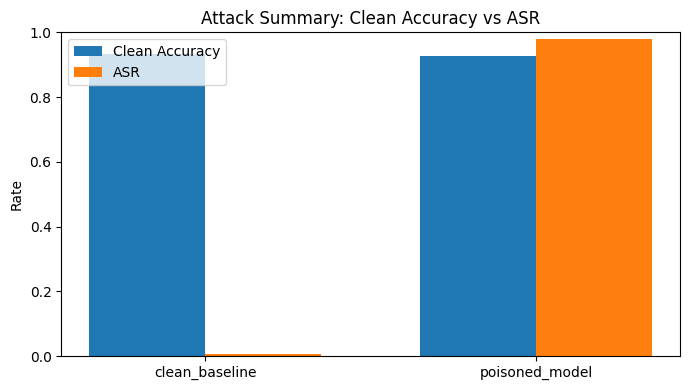

In [13]:
attack_summary = pd.DataFrame({
    "model": ["clean_baseline", "poisoned_model"],
    "clean_accuracy": [clean_test_acc, poisoned_test_acc],
    "ASR": [clean_asr, poisoned_asr]
})
attack_summary.to_csv(META_DIR / "attack_summary.csv", index=False)

x = np.arange(len(attack_summary))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, attack_summary["clean_accuracy"], width, label="Clean Accuracy")
plt.bar(x + width/2, attack_summary["ASR"], width, label="ASR")
plt.xticks(x, attack_summary["model"])
plt.ylim(0, 1.0)
plt.ylabel("Rate")
plt.title("Attack Summary: Clean Accuracy vs ASR")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "attack_summary.png", dpi=200)
plt.show()

### Activation clustering
We now detect suspicious poisoned samples from the poisoned training set.

Assignment-aligned procedure:
1. Extract penultimate-layer features
2. Keep only samples whose observed label equals the target class
3. Standardize features
4. Reduce dimensionality with FastICA (fallback to PCA)
5. Cluster into 2 groups with k-means
6. Use the smaller cluster as suspicious

#### Feature extraction from poisoned training data

In [14]:
@torch.no_grad()
def extract_target_class_features(model, dataset, device, target_class, batch_size=256, num_workers=2):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)

    model.eval()

    features = []
    observed_labels = []
    original_labels = []
    poison_flags = []
    original_indices = []
    subset_positions = []
    images = []

    for batch in loader:
        imgs = batch[0].to(device)
        obs_labels = batch[1]
        orig_labels = batch[2]
        is_poisoned = batch[3]
        orig_idx = batch[4]
        subset_pos = batch[5]

        feats = model.forward_features(imgs).cpu().numpy()
        imgs_cpu = batch[0].numpy()

        mask = (obs_labels.numpy() == target_class)

        if mask.sum() == 0:
            continue

        features.append(feats[mask])
        observed_labels.append(obs_labels.numpy()[mask])
        original_labels.append(orig_labels.numpy()[mask])
        poison_flags.append(is_poisoned.numpy()[mask])
        original_indices.append(orig_idx.numpy()[mask])
        subset_positions.append(subset_pos.numpy()[mask])
        images.append(imgs_cpu[mask])

    features = np.concatenate(features, axis=0)
    observed_labels = np.concatenate(observed_labels, axis=0)
    original_labels = np.concatenate(original_labels, axis=0)
    poison_flags = np.concatenate(poison_flags, axis=0).astype(int)
    original_indices = np.concatenate(original_indices, axis=0)
    subset_positions = np.concatenate(subset_positions, axis=0)
    images = np.concatenate(images, axis=0)

    return {
        "features": features,
        "observed_labels": observed_labels,
        "original_labels": original_labels,
        "poison_flags": poison_flags,
        "original_indices": original_indices,
        "subset_positions": subset_positions,
        "images": images,
    }

feature_pack = extract_target_class_features(
    poisoned_model,
    poisoned_train_eval_ds,
    CONFIG["device"],
    target_class=CONFIG["target_class"],
    batch_size=CONFIG["feature_batch_size"],
    num_workers=CONFIG["num_workers"]
)

for k, v in feature_pack.items():
    print(k, np.array(v).shape)

features (6525, 512)
observed_labels (6525,)
original_labels (6525,)
poison_flags (6525,)
original_indices (6525,)
subset_positions (6525,)
images (6525, 3, 32, 32)


#### Standardize, reduce, cluster

In [15]:
X = feature_pack["features"]
y_true_poison = feature_pack["poison_flags"]

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

reducer_name = "FastICA"
try:
    reducer = FastICA(
        n_components=CONFIG["ica_components"],
        random_state=CONFIG["seed"],
        whiten="unit-variance",
        max_iter=1000
    )
    X_red = reducer.fit_transform(X_std)
except Exception as e:
    print("FastICA failed, falling back to PCA. Reason:", e)
    reducer_name = "PCA"
    reducer = PCA(n_components=CONFIG["ica_components"], random_state=CONFIG["seed"])
    X_red = reducer.fit_transform(X_std)

kmeans = KMeans(n_clusters=2, n_init=CONFIG["kmeans_n_init"], random_state=CONFIG["seed"])
clusters = kmeans.fit_predict(X_red)

cluster_sizes = pd.Series(clusters).value_counts().sort_index()
suspicious_cluster = cluster_sizes.idxmin()   # smaller cluster heuristic

y_pred_suspicious = (clusters == suspicious_cluster).astype(int)

print("Reducer used:", reducer_name)
print("Cluster sizes:\n", cluster_sizes)
print("Suspicious cluster:", suspicious_cluster)

Reducer used: FastICA
Cluster sizes:
 0    4527
1    1998
Name: count, dtype: int64
Suspicious cluster: 1


#### Detection metrics

In [16]:
precision = precision_score(y_true_poison, y_pred_suspicious, zero_division=0)
recall = recall_score(y_true_poison, y_pred_suspicious, zero_division=0)
f1 = f1_score(y_true_poison, y_pred_suspicious, zero_division=0)

detection_metrics = {
    "precision": float(precision),
    "recall": float(recall),
    "f1": float(f1),
    "num_target_labeled_samples_clustered": int(len(y_true_poison)),
    "num_true_poison_in_clustered_subset": int(y_true_poison.sum()),
    "num_predicted_suspicious": int(y_pred_suspicious.sum()),
    "reducer": reducer_name,
}

with open(META_DIR / "detection_metrics.json", "w") as f:
    json.dump(detection_metrics, f, indent=2)

print(json.dumps(detection_metrics, indent=2))

{
  "precision": 0.9984984984984985,
  "recall": 0.9851851851851852,
  "f1": 0.9917971662938105,
  "num_target_labeled_samples_clustered": 6525,
  "num_true_poison_in_clustered_subset": 2025,
  "num_predicted_suspicious": 1998,
  "reducer": "FastICA"
}


#### Clustering visualization

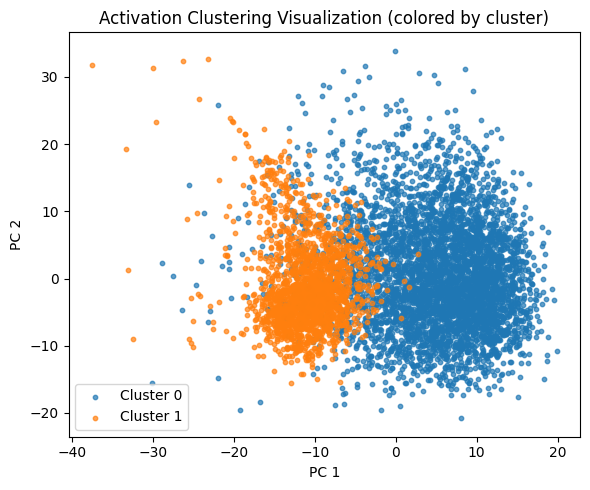

In [17]:
# Use PCA to 2D for a stable visualization, regardless of whether ICA/PCA was used above
viz_2d = PCA(n_components=2, random_state=CONFIG["seed"]).fit_transform(X_std)

plt.figure(figsize=(6, 5))
for cluster_id in [0, 1]:
    mask = clusters == cluster_id
    plt.scatter(
        viz_2d[mask, 0],
        viz_2d[mask, 1],
        s=10,
        alpha=0.7,
        label=f"Cluster {cluster_id}"
    )

plt.title("Activation Clustering Visualization (colored by cluster)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "clustering_visualization.png", dpi=200)
plt.show()

cluster_results_df = pd.DataFrame({
    "original_index": feature_pack["original_indices"],
    "subset_position": feature_pack["subset_positions"],
    "observed_label": feature_pack["observed_labels"],
    "original_label": feature_pack["original_labels"],
    "is_true_poison": y_true_poison,
    "cluster": clusters,
    "predicted_suspicious": y_pred_suspicious,
})
cluster_results_df.to_csv(META_DIR / "cluster_results.csv", index=False)

#### Cluster sample visualization

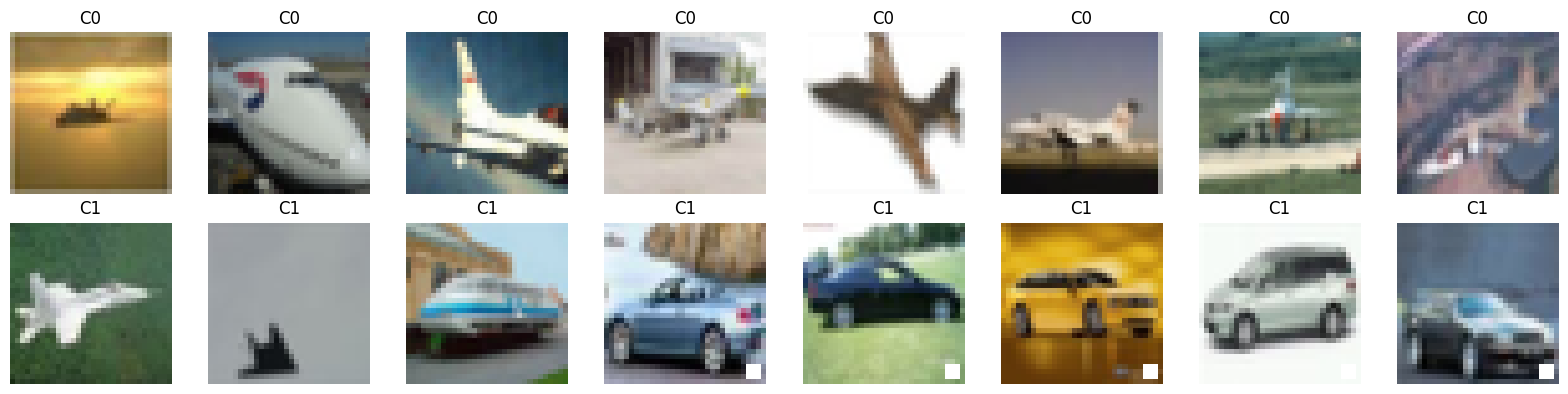

In [18]:
def show_cluster_examples(images, clusters, num_show=8):
    fig, axes = plt.subplots(2, num_show, figsize=(2*num_show, 4))
    for row, cluster_id in enumerate([0, 1]):
        idxs = np.where(clusters == cluster_id)[0][:num_show]
        for col in range(num_show):
            ax = axes[row, col]
            ax.axis("off")
            if col < len(idxs):
                img = images[idxs[col]]
                ax.imshow(np.transpose(img, (1, 2, 0)))
                ax.set_title(f"C{cluster_id}")
    plt.tight_layout()
    plt.show()

show_cluster_examples(feature_pack["images"], clusters, num_show=8)

### Repair
We remove all samples assigned to the suspicious cluster, then retrain a fresh ResNet-18 from scratch on the filtered dataset.

#### Build filtered training set

In [19]:
# Suspicious target-labeled subset positions identified by clustering
suspicious_subset_positions = set(
    feature_pack["subset_positions"][y_pred_suspicious == 1].tolist()
)

# Keep all original training subset positions except those flagged suspicious
filtered_keep_mask = np.array([
    (i not in suspicious_subset_positions) for i in range(len(train_indices))
])

print("Original poisoned train size:", len(train_indices))
print("Filtered train size:", int(filtered_keep_mask.sum()))
print("Removed samples:", int((~filtered_keep_mask).sum()))

filtered_indices = train_indices[filtered_keep_mask]
filtered_poison_mask = poison_mask_train_subset[filtered_keep_mask]

filtered_meta = pd.DataFrame({
    "original_index": filtered_indices,
    "is_poisoned_after_filter": filtered_poison_mask.astype(int)
})
filtered_meta.to_csv(META_DIR / "filtered_train_metadata.csv", index=False)

repaired_train_ds = PoisonedCIFAR10Train(
    root=CONFIG["data_dir"],
    indices=filtered_indices,
    poison_mask_subset=filtered_poison_mask,
    target_class=CONFIG["target_class"],
    transform=train_transform,
    trigger_size=CONFIG["trigger_size"],
    trigger_value=CONFIG["trigger_value"],
    trigger_offset=CONFIG["trigger_offset"],
)

repaired_train_loader = DataLoader(
    repaired_train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True
)

Original poisoned train size: 45000
Filtered train size: 43002
Removed samples: 1998


#### Retrain repaired model

In [20]:
repaired_model = ResNet18WithFeatures(num_classes=CONFIG["num_classes"]).to(CONFIG["device"])
repaired_model, repaired_history, repaired_best_val = train_model(
    repaired_model,
    repaired_train_loader,
    val_loader,
    CONFIG["device"],
    model_name="repaired_model"
)

repaired_test_acc = evaluate_clean_accuracy(repaired_model, test_loader, CONFIG["device"])
repaired_asr = evaluate_asr(repaired_model, triggered_test_loader, CONFIG["device"], CONFIG["target_class"])

print("Repaired model clean test accuracy:", repaired_test_acc)
print("Repaired model ASR:", repaired_asr)

[repaired_model] Epoch 01/30 | train_loss=2.0108 | train_acc=0.2795 | val_acc=0.2284
[repaired_model] Epoch 02/30 | train_loss=1.4617 | train_acc=0.4604 | val_acc=0.3910
[repaired_model] Epoch 03/30 | train_loss=1.1915 | train_acc=0.5696 | val_acc=0.5882
[repaired_model] Epoch 04/30 | train_loss=0.9724 | train_acc=0.6545 | val_acc=0.5204
[repaired_model] Epoch 05/30 | train_loss=0.8069 | train_acc=0.7185 | val_acc=0.7058
[repaired_model] Epoch 06/30 | train_loss=0.6921 | train_acc=0.7611 | val_acc=0.6870
[repaired_model] Epoch 07/30 | train_loss=0.6090 | train_acc=0.7904 | val_acc=0.7418
[repaired_model] Epoch 08/30 | train_loss=0.5564 | train_acc=0.8081 | val_acc=0.7726
[repaired_model] Epoch 09/30 | train_loss=0.5157 | train_acc=0.8236 | val_acc=0.7670
[repaired_model] Epoch 10/30 | train_loss=0.4852 | train_acc=0.8345 | val_acc=0.7898
[repaired_model] Epoch 11/30 | train_loss=0.4505 | train_acc=0.8463 | val_acc=0.8066
[repaired_model] Epoch 12/30 | train_loss=0.4263 | train_acc=0.85

#### Final comparison and repair summary plot

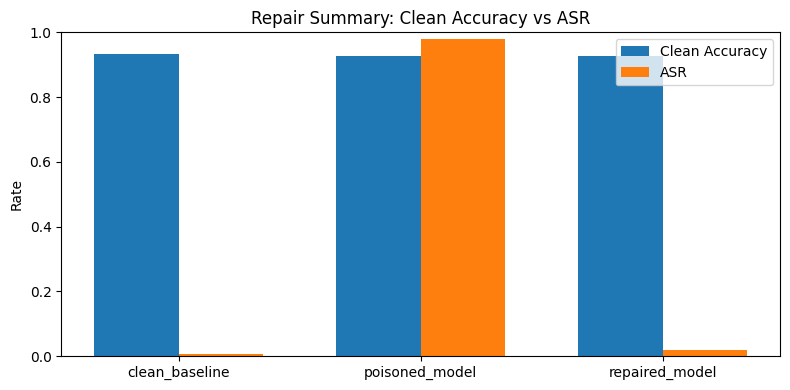

            model  clean_accuracy       ASR
0  clean_baseline          0.9327  0.007556
1  poisoned_model          0.9258  0.980556
2  repaired_model          0.9262  0.019111


In [21]:
final_summary = pd.DataFrame({
    "model": ["clean_baseline", "poisoned_model", "repaired_model"],
    "clean_accuracy": [clean_test_acc, poisoned_test_acc, repaired_test_acc],
    "ASR": [clean_asr, poisoned_asr, repaired_asr]
})
final_summary.to_csv(META_DIR / "final_summary.csv", index=False)

x = np.arange(len(final_summary))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, final_summary["clean_accuracy"], width, label="Clean Accuracy")
plt.bar(x + width/2, final_summary["ASR"], width, label="ASR")
plt.xticks(x, final_summary["model"])
plt.ylim(0, 1.0)
plt.ylabel("Rate")
plt.title("Repair Summary: Clean Accuracy vs ASR")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "repair_summary.png", dpi=200)
plt.show()

print(final_summary)

In [22]:
# Save combined metrics
all_metrics = {
    "clean_baseline": {
        "clean_test_accuracy": float(clean_test_acc),
        "ASR": float(clean_asr),
    },
    "poisoned_model": {
        "clean_test_accuracy": float(poisoned_test_acc),
        "ASR": float(poisoned_asr),
    },
    "repaired_model": {
        "clean_test_accuracy": float(repaired_test_acc),
        "ASR": float(repaired_asr),
    },
    "detection": detection_metrics,
}

with open(OUT_DIR / "all_metrics.json", "w") as f:
    json.dump(all_metrics, f, indent=2)

print(json.dumps(all_metrics, indent=2))

{
  "clean_baseline": {
    "clean_test_accuracy": 0.9327,
    "ASR": 0.007555555555555556
  },
  "poisoned_model": {
    "clean_test_accuracy": 0.9258,
    "ASR": 0.9805555555555555
  },
  "repaired_model": {
    "clean_test_accuracy": 0.9262,
    "ASR": 0.01911111111111111
  },
  "detection": {
    "precision": 0.9984984984984985,
    "recall": 0.9851851851851852,
    "f1": 0.9917971662938105,
    "num_target_labeled_samples_clustered": 6525,
    "num_true_poison_in_clustered_subset": 2025,
    "num_predicted_suspicious": 1998,
    "reducer": "FastICA"
  }
}
